# ECG Heartbeat Classification Project
## Phase 3 (EDA and Feature Extraction)
Performing exploratory data analysis on the segmented
heartbeat dataset and extracting meaningful features from each beat
for use in machine learning classification in Phase 4.

### Import libraries and load saved dataset

In [12]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter

# loading the dataset
data_path = '../data'

X = np.load(os.path.join(data_path, 'X_beats.npy'))
y = np.load(os.path.join(data_path, 'y_labels.npy'))
y_binary = np.load(os.path.join(data_path, 'y_binary.npy'))

print("Dataset loaded successfully!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y_binary shape: {y_binary.shape}")
print(f"\nClass distribution:")
for label, count in Counter(y).most_common():
    print(f"  {label}: {count} ({count/len(y)*100:.1f}%)")

Dataset loaded successfully!
X shape: (102382, 360)
y shape: (102382,)
y_binary shape: (102382,)

Class distribution:
  N: 75011 (73.3%)
  L: 8071 (7.9%)
  R: 7255 (7.1%)
  V: 7129 (7.0%)
  A: 2546 (2.5%)
  f: 982 (1.0%)
  F: 802 (0.8%)
  j: 229 (0.2%)
  a: 150 (0.1%)
  E: 106 (0.1%)
  J: 83 (0.1%)
  e: 16 (0.0%)
  S: 2 (0.0%)


### Visualise average beat shape per class

#### Normal beat baseline reference

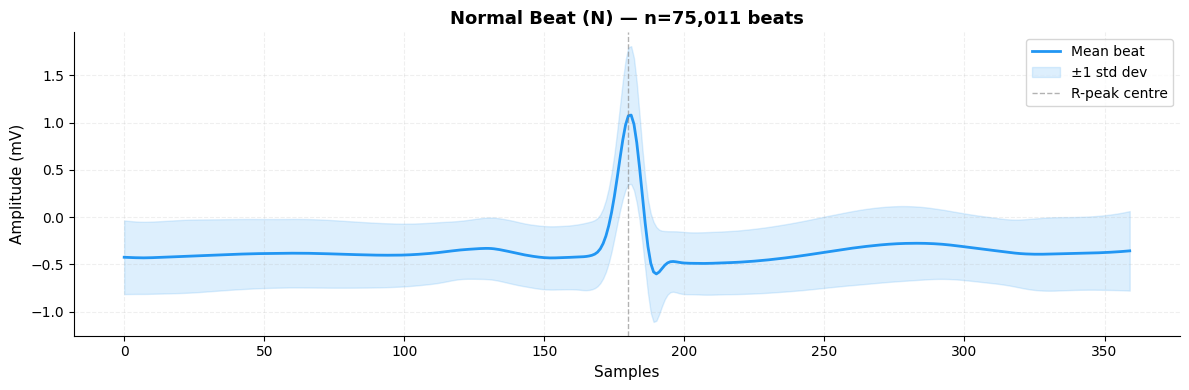

Normal beats: 75,011 out of 102,382 total (73.3%)
Mean R-peak amplitude: 1.073 mV
Mean std deviation: 0.370 mV


In [6]:
indices_n = np.where(y == 'N')[0]
mean_n = np.mean(X[indices_n], axis=0)
std_n = np.std(X[indices_n], axis=0)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(mean_n, color='#2196F3', linewidth=2, label='Mean beat')
ax.fill_between(range(360),
                mean_n - std_n,
                mean_n + std_n,
                alpha=0.15, color='#2196F3', label='±1 std dev')
ax.axvline(x=180, color='gray', linestyle='--', alpha=0.6, linewidth=1, label='R-peak centre')

ax.set_title(f'Normal Beat (N) — n={len(indices_n):,} beats', fontsize=13, fontweight='bold')
ax.set_xlabel('Samples', fontsize=11)
ax.set_ylabel('Amplitude (mV)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Normal beats: {len(indices_n):,} out of {len(y):,} total ({len(indices_n)/len(y)*100:.1f}%)")
print(f"Mean R-peak amplitude: {mean_n[180]:.3f} mV")
print(f"Mean std deviation: {np.mean(std_n):.3f} mV")

#### Bundle branch block beats (Left and Right)
These beats occur when the electrical signal takes the wrong path
through the left or right side of the heart.

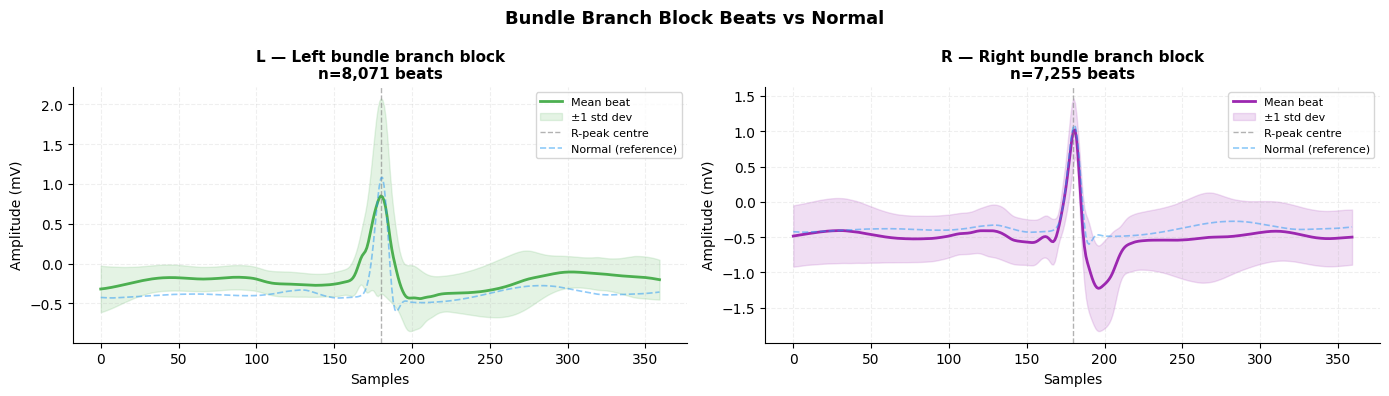

Left bundle branch block (L): 8,071 beats (7.9%)
Right bundle branch block (R): 7,255 beats (7.1%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bundle_types = [('L', '#4CAF50', 'Left bundle branch block'),
                ('R', '#9C27B0', 'Right bundle branch block')]

for ax, (beat_type, color, name) in zip(axes, bundle_types):
    indices = np.where(y == beat_type)[0]
    mean_beat = np.mean(X[indices], axis=0)
    std_beat = np.std(X[indices], axis=0)

    ax.plot(mean_beat, color=color, linewidth=2, label='Mean beat')
    ax.fill_between(range(360),
                    mean_beat - std_beat,
                    mean_beat + std_beat,
                    alpha=0.15, color=color, label='±1 std dev')
    ax.axvline(x=180, color='gray', linestyle='--',
               alpha=0.6, linewidth=1, label='R-peak centre')

    # Also overlay Normal beat for comparison
    ax.plot(mean_n, color='#2196F3', linewidth=1.2,
            linestyle='--', alpha=0.5, label='Normal (reference)')

    ax.set_title(f'{beat_type} — {name}\nn={len(indices):,} beats',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Samples', fontsize=10)
    ax.set_ylabel('Amplitude (mV)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Bundle Branch Block Beats vs Normal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for beat_type, _, name in bundle_types:
    indices = np.where(y == beat_type)[0]
    print(f"{name} ({beat_type}): {len(indices):,} beats ({len(indices)/len(y)*100:.1f}%)")

#### Premature beats (Ventricular and Atrial)
These beats occur when the heart fires too early before the normal
electrical signal arrives.

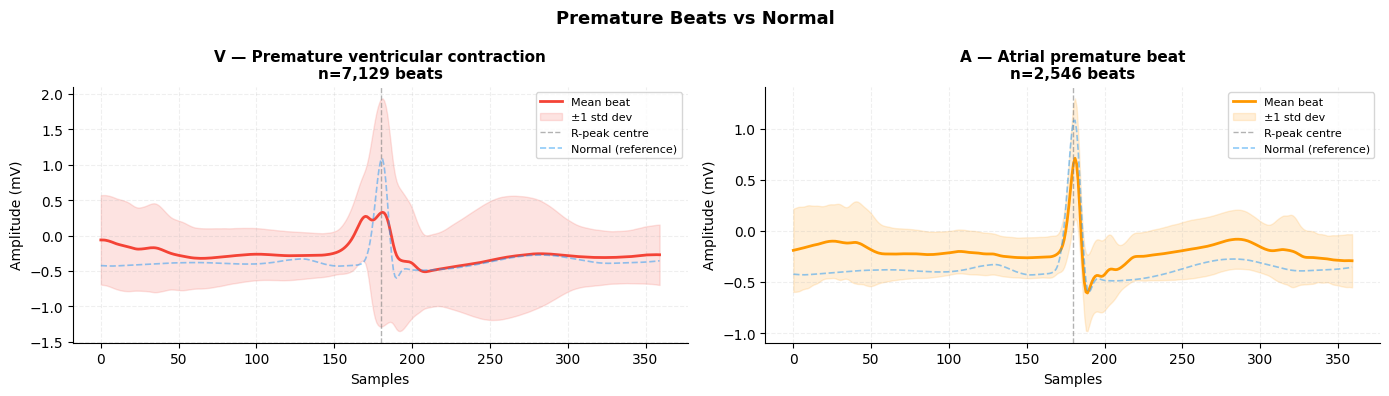

Premature ventricular contraction (V): 7,129 beats (7.0%)
Atrial premature beat (A): 2,546 beats (2.5%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

premature_types = [('V', '#F44336', 'Premature ventricular contraction'),
                   ('A', '#FF9800', 'Atrial premature beat')]

for ax, (beat_type, color, name) in zip(axes, premature_types):
    indices = np.where(y == beat_type)[0]
    mean_beat = np.mean(X[indices], axis=0)
    std_beat = np.std(X[indices], axis=0)

    ax.plot(mean_beat, color=color, linewidth=2, label='Mean beat')
    ax.fill_between(range(360),
                    mean_beat - std_beat,
                    mean_beat + std_beat,
                    alpha=0.15, color=color, label='±1 std dev')
    ax.axvline(x=180, color='gray', linestyle='--',
               alpha=0.6, linewidth=1, label='R-peak centre')

    # Overlay Normal beat for comparison
    ax.plot(mean_n, color='#2196F3', linewidth=1.2,
            linestyle='--', alpha=0.5, label='Normal (reference)')

    ax.set_title(f'{beat_type} — {name}\nn={len(indices):,} beats',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Samples', fontsize=10)
    ax.set_ylabel('Amplitude (mV)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Premature Beats vs Normal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for beat_type, _, name in premature_types:
    indices = np.where(y == beat_type)[0]
    print(f"{name} ({beat_type}): {len(indices):,} beats ({len(indices)/len(y)*100:.1f}%)")

### Observations from average beat shapes

The average beat shape plots reveal clear visual differences between
beat types across all 48 records:

- **Normal (N):** Sharp consistent R-peak at sample 180 with narrow
  standard deviation band, indicating high consistency across patients.

- **Left Bundle Branch Block (L):** Similar peak position to Normal
  but with distinctly different morphology around the QRS complex,
  reflecting the abnormal electrical conduction pathway.

- **Right Bundle Branch Block (R):** Notably inverted peak compared
  to Normal — the R-peak goes negative — due to reversed electrical
  signal direction through the right ventricle.

- **PVC (V):** Very wide standard deviation band indicating high
  variability across patients. The mean shape is almost flat,
  showing how differently PVC beats manifest between individuals.

- **Atrial Premature (A):** Visually most similar to Normal, confirming
  that A beats will be the most challenging class for the ML model
  to distinguish correctly in Phase 4.

### Class distribution(Frequency Distribution Chart)
Visualising the frequency of each beat type across all 48 patients.


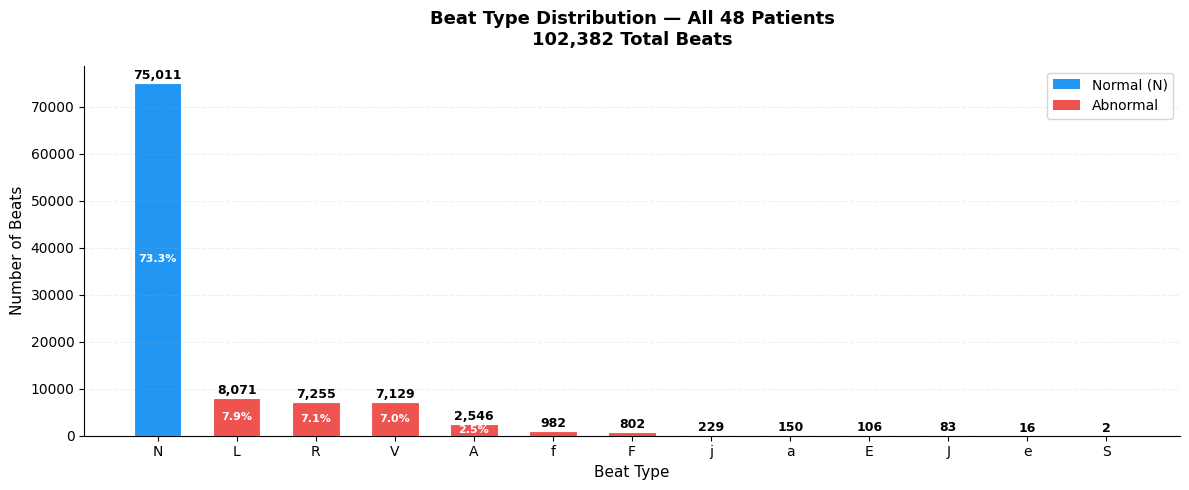

Beat type summary:
  N: 75,011 beats (73.3%)
  L: 8,071 beats (7.9%)
  R: 7,255 beats (7.1%)
  V: 7,129 beats (7.0%)
  A: 2,546 beats (2.5%)
  f: 982 beats (1.0%)
  F: 802 beats (0.8%)
  j: 229 beats (0.2%)
  a: 150 beats (0.1%)
  E: 106 beats (0.1%)
  J: 83 beats (0.1%)
  e: 16 beats (0.0%)
  S: 2 beats (0.0%)


In [10]:
label_counts = Counter(y)
symbols = [item[0] for item in sorted(label_counts.items(),
           key=lambda x: -x[1])]
counts = [item[1] for item in sorted(label_counts.items(),
          key=lambda x: -x[1])]

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#2196F3' if s == 'N' else '#EF5350' for s in symbols]
bars = ax.bar(symbols, counts, color=colors,
              edgecolor='white', linewidth=0.8, width=0.6)

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{count:,}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add percentage labels inside each bar
for bar, count in zip(bars, counts):
    percentage = count / len(y) * 100
    if percentage > 1.5:  # only show if bar is tall enough
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() / 2,
                f'{percentage:.1f}%',
                ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

ax.set_title('Beat Type Distribution — All 48 Patients\n102,382 Total Beats',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Beat Type', fontsize=11)
ax.set_ylabel('Number of Beats', fontsize=11)
ax.grid(True, alpha=0.2, linestyle='--', axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Normal (N)'),
                   Patch(facecolor='#EF5350', label='Abnormal')]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

print("Beat type summary:")
for symbol, count in zip(symbols, counts):
    print(f"  {symbol}: {count:,} beats ({count/len(y)*100:.1f}%)")

### Observations from class distribution

The bar chart clearly shows the class imbalance across the dataset:

- Normal beats (N) dominate with 75,011 beats — 73.3% of the entire dataset
- The remaining 26.7% is spread across 12 different abnormal beat types
- L, R and V are the most common abnormal types with roughly 7,000-8,000 each
- Rare types like S (2 beats) and e (16 beats) have very few examples

This imbalance means the ML model in Phase 4 must use class_weight=balanced
to prevent it from being biased towards predicting everything as Normal.
Without this correction a naive model could achieve 73.3% accuracy by simply
always predicting Normal, which would be medically useless as it would miss
every single abnormal heartbeat.

## Feature Extraction
Describing the Overall shape of the dataset with the mean, Standard Deviation, MAx value, min value, skewness and so on.
Extracting 14 meaningful features from each heartbeat segment.
These features capture the most clinically relevant characteristics
of each beat and will be used as input for the ML model in Phase 4.

### Feature 1 — Mean amplitude
The mean is the average voltage across all 360 samples of a heartbeat.
It captures the overall baseline level of the signal.
A higher mean suggests more positive voltage overall — a lower mean
suggests more negative voltage. Different beat types sit at
different baseline levels making this a useful classification feature.

Mean calculated for all 102,382 beats

First 10 beats:
  Beat 0: mean = -0.3098 mV  → Normal
  Beat 1: mean = -0.3324 mV  → Normal
  Beat 2: mean = -0.3330 mV  → Normal
  Beat 3: mean = -0.3320 mV  → Normal
  Beat 4: mean = -0.3258 mV  → Normal
  Beat 5: mean = -0.3028 mV  → Normal
  Beat 6: mean = -0.3316 mV  → Abnormal
  Beat 7: mean = -0.3558 mV  → Normal
  Beat 8: mean = -0.3339 mV  → Normal
  Beat 9: mean = -0.3088 mV  → Normal

Normal beats (75,011 beats):
  Average mean value: -0.3520 mV
  Std of mean values: 0.3100 mV
  Min: -5.0000  Max: 4.8896

Abnormal beats (27,371 beats):
  Average mean value: -0.2876 mV
  Std of mean values: 0.2931 mV
  Min: -2.4282  Max: 2.1426


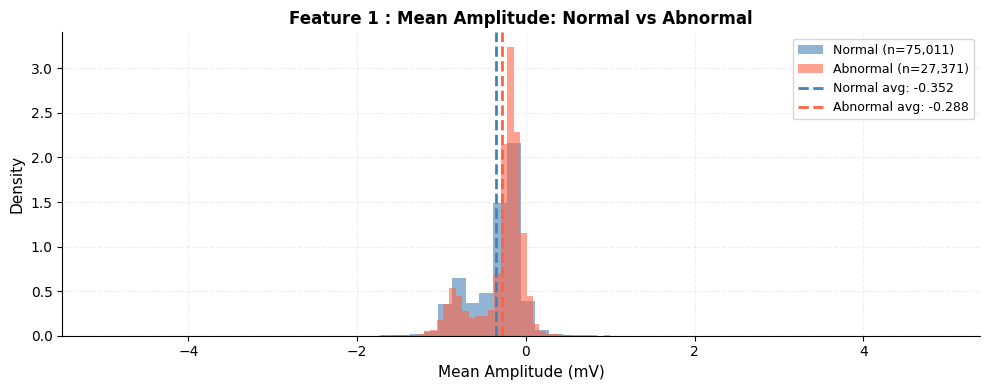

In [21]:
# Calculate mean for every single beat
# axis=1 means calculate across columns (across the 360 samples)
# giving us one mean value per row (per beat)
mean_values = np.mean(X, axis=1)

print(f"Mean calculated for all {len(mean_values):,} beats")
print(f"\nFirst 10 beats:")
for i in range(10):
    label_name = "Normal" if y_binary[i] == 0 else "Abnormal"
    print(f"  Beat {i}: mean = {mean_values[i]:.4f} mV  → {label_name}")

# Separate Normal and Abnormal
normal_mean = mean_values[y_binary == 0]
abnormal_mean = mean_values[y_binary == 1]

print(f"\nNormal beats ({len(normal_mean):,} beats):")
print(f"  Average mean value: {np.mean(normal_mean):.4f} mV")
print(f"  Std of mean values: {np.std(normal_mean):.4f} mV")
print(f"  Min: {np.min(normal_mean):.4f}  Max: {np.max(normal_mean):.4f}")

print(f"\nAbnormal beats ({len(abnormal_mean):,} beats):")
print(f"  Average mean value: {np.mean(abnormal_mean):.4f} mV")
print(f"  Std of mean values: {np.std(abnormal_mean):.4f} mV")
print(f"  Min: {np.min(abnormal_mean):.4f}  Max: {np.max(abnormal_mean):.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(normal_mean, bins=60, alpha=0.6,
        color='steelblue', label=f'Normal (n={len(normal_mean):,})',
        density=True)
ax.hist(abnormal_mean, bins=60, alpha=0.6,
        color='tomato', label=f'Abnormal (n={len(abnormal_mean):,})',
        density=True)
ax.axvline(np.mean(normal_mean), color='steelblue',
           linestyle='--', linewidth=2,
           label=f'Normal avg: {np.mean(normal_mean):.3f}')
ax.axvline(np.mean(abnormal_mean), color='tomato',
           linestyle='--', linewidth=2,
           label=f'Abnormal avg: {np.mean(abnormal_mean):.3f}')
ax.set_title('Feature 1 : Mean Amplitude: Normal vs Abnormal',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Amplitude (mV)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Observations — Mean amplitude

- Normal beats have an average mean of −0.352 mV
- Abnormal beats have a slightly higher average mean of −0.288 mV
- The difference is small (0.064 mV) meaning mean alone cannot
  reliably separate Normal from Abnormal beats
- The histogram shows heavily overlapping distributions confirming
  this observation
- However mean still contributes useful information when combined
  with other features in the ML model
- Normal beats show wider range (−5.0 to 4.89) due to natural
  variation across 75,011 beats from 48 different patients

### Feature 2 — Standard deviation
Standard deviation measures how much the voltage fluctuates across
the 360 samples of each heartbeat. A low value means the signal is
mostly flat with one sharp spike, typical of Normal beats. A high
value means the voltage swings widely throughout the beat, more
typical of abnormal beat types like PVC and Bundle Branch Block.

Standard deviation calculated for all 102,382 beats

First 10 beats:
  Beat 0: std = 0.1691 mV  → Normal
  Beat 1: std = 0.1536 mV  → Normal
  Beat 2: std = 0.1458 mV  → Normal
  Beat 3: std = 0.1382 mV  → Normal
  Beat 4: std = 0.1469 mV  → Normal
  Beat 5: std = 0.1557 mV  → Normal
  Beat 6: std = 0.1508 mV  → Abnormal
  Beat 7: std = 0.1613 mV  → Normal
  Beat 8: std = 0.1500 mV  → Normal
  Beat 9: std = 0.1467 mV  → Normal

Normal beats (75,011 beats):
  Average std: 0.2698 mV
  Std of stds: 0.1131 mV
  Min: 0.0248  Max: 3.5708

Abnormal beats (27,371 beats):
  Average std: 0.3739 mV
  Std of stds: 0.1743 mV
  Min: 0.0577  Max: 1.2602

Difference in average std:
  Abnormal − Normal = 0.1040 mV
  Abnormal beats have HIGHER variation than Normal beats


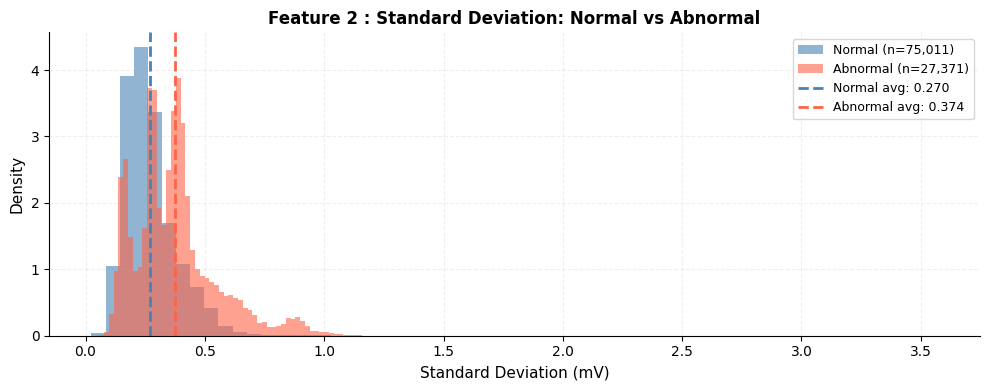

In [20]:
# Calculate standard deviation for every single beat
# axis=1 means calculate across the 360 samples for each beat
std_values = np.std(X, axis=1)

print(f"Standard deviation calculated for all {len(std_values):,} beats")
print(f"\nFirst 10 beats:")
for i in range(10):
    label_name = "Normal" if y_binary[i] == 0 else "Abnormal"
    print(f"  Beat {i}: std = {std_values[i]:.4f} mV  → {label_name}")

# Separate Normal and Abnormal
normal_std = std_values[y_binary == 0]
abnormal_std = std_values[y_binary == 1]

print(f"\nNormal beats ({len(normal_std):,} beats):")
print(f"  Average std: {np.mean(normal_std):.4f} mV")
print(f"  Std of stds: {np.std(normal_std):.4f} mV")
print(f"  Min: {np.min(normal_std):.4f}  Max: {np.max(normal_std):.4f}")

print(f"\nAbnormal beats ({len(abnormal_std):,} beats):")
print(f"  Average std: {np.mean(abnormal_std):.4f} mV")
print(f"  Std of stds: {np.std(abnormal_std):.4f} mV")
print(f"  Min: {np.min(abnormal_std):.4f}  Max: {np.max(abnormal_std):.4f}")

print(f"\nDifference in average std:")
diff = np.mean(abnormal_std) - np.mean(normal_std)
print(f"  Abnormal − Normal = {diff:.4f} mV")
if diff > 0:
    print(f"  Abnormal beats have HIGHER variation than Normal beats")
else:
    print(f"  Abnormal beats have LOWER variation than Normal beats")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(normal_std, bins=60, alpha=0.6,
        color='steelblue', label=f'Normal (n={len(normal_std):,})',
        density=True)
ax.hist(abnormal_std, bins=60, alpha=0.6,
        color='tomato', label=f'Abnormal (n={len(abnormal_std):,})',
        density=True)
ax.axvline(np.mean(normal_std), color='steelblue',
           linestyle='--', linewidth=2,
           label=f'Normal avg: {np.mean(normal_std):.3f}')
ax.axvline(np.mean(abnormal_std), color='tomato',
           linestyle='--', linewidth=2,
           label=f'Abnormal avg: {np.mean(abnormal_std):.3f}')
ax.set_title('Feature 2 : Standard Deviation: Normal vs Abnormal',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Standard Deviation (mV)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Observations: Standard deviation

- Normal beats have an average std of 0.270 mV
- Abnormal beats have a higher average std of 0.374 mV
- The difference of 0.104 mV is larger than the mean difference
  of 0.064 mV — confirming std is a more powerful feature
- Abnormal beats have HIGHER variation than Normal beats because
  abnormal electrical pathways create wider and more complex
  beat shapes
- The histogram shows more separation between Normal and Abnormal
  compared to Feature 1 — std will contribute more to the ML model
- Normal beats have a wider maximum range (up to 3.57) due to the
  large number of beats from 48 different patients

### Feature 3 : R-peak amplitude
The R-peak amplitude is the voltage at exactly sample 180 — the
centre of every heartbeat window. Since we centred every beat on
the R-peak during segmentation, sample 180 always corresponds to
the peak of the main spike. This is the most clinically important
feature as it directly measures the strength and direction of the
heart's main electrical discharge. Right Bundle Branch Block beats
are expected to show negative R-peak values as their electrical
signal travels in the opposite direction.

R-peak amplitude calculated for all 102,382 beats

First 10 beats:
  Beat 0: R-peak = 0.9400 mV  → Normal
  Beat 1: R-peak = 0.8850 mV  → Normal
  Beat 2: R-peak = 0.8100 mV  → Normal
  Beat 3: R-peak = 0.8200 mV  → Normal
  Beat 4: R-peak = 0.8850 mV  → Normal
  Beat 5: R-peak = 0.9450 mV  → Normal
  Beat 6: R-peak = 0.8450 mV  → Abnormal
  Beat 7: R-peak = 0.8450 mV  → Normal
  Beat 8: R-peak = 0.8900 mV  → Normal
  Beat 9: R-peak = 0.9250 mV  → Normal

Normal beats (75,011 beats):
  Average R-peak: 1.0727 mV
  Std:            0.7236 mV
  Min: -5.1200  Max: 5.1150
  Negative R-peaks: 6,437 beats

Abnormal beats (27,371 beats):
  Average R-peak: 0.7755 mV
  Std:            1.1596 mV
  Min: -3.9550  Max: 3.6350
  Negative R-peaks: 4,106 beats

Difference in average R-peak:
  Abnormal − Normal = -0.2972 mV

Average R-peak by beat type:
  N: 1.0727 mV
  L: 0.8489 mV
  R: 1.0044 mV
  V: 0.3199 mV
  A: 0.6577 mV


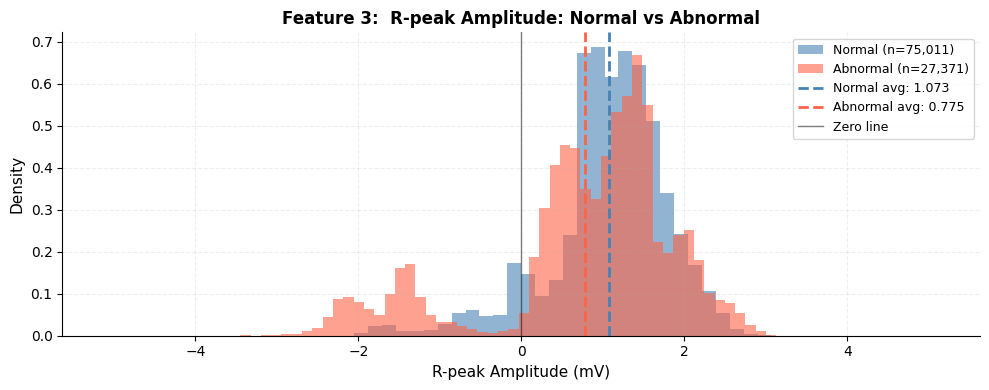

In [23]:
# R-peak is always at sample 180 — the centre of our window
# This is guaranteed because we centred every beat on the R-peak
# during segmentation in Phase 2
r_peak_values = X[:, 180]

print(f"R-peak amplitude calculated for all {len(r_peak_values):,} beats")
print(f"\nFirst 10 beats:")
for i in range(10):
    label_name = "Normal" if y_binary[i] == 0 else "Abnormal"
    print(f"  Beat {i}: R-peak = {r_peak_values[i]:.4f} mV  → {label_name}")

# Separate Normal and Abnormal
normal_rpeak = r_peak_values[y_binary == 0]
abnormal_rpeak = r_peak_values[y_binary == 1]

print(f"\nNormal beats ({len(normal_rpeak):,} beats):")
print(f"  Average R-peak: {np.mean(normal_rpeak):.4f} mV")
print(f"  Std:            {np.std(normal_rpeak):.4f} mV")
print(f"  Min: {np.min(normal_rpeak):.4f}  Max: {np.max(normal_rpeak):.4f}")
print(f"  Negative R-peaks: {np.sum(normal_rpeak < 0):,} beats")

print(f"\nAbnormal beats ({len(abnormal_rpeak):,} beats):")
print(f"  Average R-peak: {np.mean(abnormal_rpeak):.4f} mV")
print(f"  Std:            {np.std(abnormal_rpeak):.4f} mV")
print(f"  Min: {np.min(abnormal_rpeak):.4f}  Max: {np.max(abnormal_rpeak):.4f}")
print(f"  Negative R-peaks: {np.sum(abnormal_rpeak < 0):,} beats")

print(f"\nDifference in average R-peak:")
diff = np.mean(abnormal_rpeak) - np.mean(normal_rpeak)
print(f"  Abnormal − Normal = {diff:.4f} mV")

# Breakdown by beat type
print(f"\nAverage R-peak by beat type:")
for beat_type in ['N', 'L', 'R', 'V', 'A']:
    indices = np.where(y == beat_type)[0]
    avg = np.mean(X[indices, 180])
    print(f"  {beat_type}: {avg:.4f} mV")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(normal_rpeak, bins=60, alpha=0.6,
        color='steelblue', label=f'Normal (n={len(normal_rpeak):,})',
        density=True)
ax.hist(abnormal_rpeak, bins=60, alpha=0.6,
        color='tomato', label=f'Abnormal (n={len(abnormal_rpeak):,})',
        density=True)
ax.axvline(np.mean(normal_rpeak), color='steelblue',
           linestyle='--', linewidth=2,
           label=f'Normal avg: {np.mean(normal_rpeak):.3f}')
ax.axvline(np.mean(abnormal_rpeak), color='tomato',
           linestyle='--', linewidth=2,
           label=f'Abnormal avg: {np.mean(abnormal_rpeak):.3f}')
ax.axvline(0, color='black', linestyle='-',
           linewidth=1, alpha=0.5, label='Zero line')
ax.set_title('Feature 3:  R-peak Amplitude: Normal vs Abnormal',
             fontsize=12, fontweight='bold')
ax.set_xlabel('R-peak Amplitude (mV)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Observations : R-peak amplitude

- R-peak amplitude shows the largest difference between Normal and
  Abnormal beats so far — 0.297 mV compared to 0.104 mV for std
  and 0.064 mV for mean
- Normal beats have the highest average R-peak at 1.073 mV —
  reflecting the strong coordinated electrical discharge
- PVC beats (V) have a dramatically lower R-peak of only 0.320 mV —
  making them the most distinguishable beat type by this feature
- Atrial Premature beats (A) also show a reduced R-peak at 0.658 mV
- Right Bundle Branch Block (R) surprisingly shows a similar R-peak
  to Normal (1.004 mV) — confirming that R-peak amplitude alone
  cannot distinguish all beat types
- Abnormal beats are almost twice as likely to have negative R-peaks
  (15.0%) compared to Normal beats (8.6%) — reflecting abnormal
  electrical conduction directions
- R-peak amplitude is the most powerful individual feature seen so
  far and will likely be the top contributor in the ML model

### Feature 4 : QRS width
QRS width measures how wide the main spike is in each heartbeat.
It reflects how long the electrical signal takes to travel through
the ventricles. Normal beats have a narrow QRS of 0.06-0.10 seconds.
Bundle Branch Block beats have a wider QRS above 0.12 seconds because
the electrical signal has to take an abnormal detour path through
the heart muscle. This is one of the most clinically important
features for distinguishing Normal from Bundle Branch Block beats.

QRS width calculated for all 102,382 beats

First 10 beats:
  Beat 0: QRS width = 0.0194 sec  → Normal
  Beat 1: QRS width = 0.0167 sec  → Normal
  Beat 2: QRS width = 0.0167 sec  → Normal
  Beat 3: QRS width = 0.0139 sec  → Normal
  Beat 4: QRS width = 0.0167 sec  → Normal
  Beat 5: QRS width = 0.0194 sec  → Normal
  Beat 6: QRS width = 0.0194 sec  → Abnormal
  Beat 7: QRS width = 0.0167 sec  → Normal
  Beat 8: QRS width = 0.0167 sec  → Normal
  Beat 9: QRS width = 0.0167 sec  → Normal

Normal beats (75,011 beats):
  Average QRS width: 0.0381 sec
  Std:               0.0360 sec
  Min: 0.0028  Max: 0.1667
  Wide QRS (>0.12s): 5,600 beats

Abnormal beats (27,371 beats):
  Average QRS width: 0.0465 sec
  Std:               0.0290 sec
  Min: 0.0028  Max: 0.1667
  Wide QRS (>0.12s): 466 beats

Difference in average QRS width:
  Abnormal − Normal = 0.0084 sec

Average QRS width by beat type:
  N: 0.0381 sec
  L: 0.0536 sec
  R: 0.0236 sec
  V: 0.0707 sec
  A: 0.0245 sec


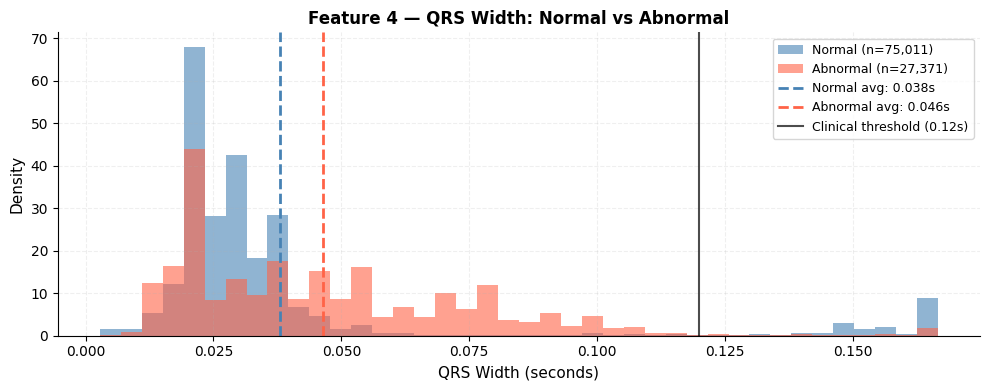

In [24]:
# Calculate QRS width for every beat
# We look at 60 samples around the R-peak (samples 150 to 210)
# and count how many are above 30% of the R-peak height

qrs_values = []

for i in range(len(X)):
    beat = X[i]
    r_peak = beat[180]
    threshold = 0.3 * r_peak
    qrs_region = beat[150:210]

    if r_peak > 0:
        qrs_samples = np.sum(qrs_region > threshold)
    else:
        qrs_samples = np.sum(qrs_region < threshold)

    qrs_width = qrs_samples / 360  # convert to seconds
    qrs_values.append(qrs_width)

qrs_values = np.array(qrs_values)

print(f"QRS width calculated for all {len(qrs_values):,} beats")
print(f"\nFirst 10 beats:")
for i in range(10):
    label_name = "Normal" if y_binary[i] == 0 else "Abnormal"
    print(f"  Beat {i}: QRS width = {qrs_values[i]:.4f} sec  → {label_name}")

# Separate Normal and Abnormal
normal_qrs = qrs_values[y_binary == 0]
abnormal_qrs = qrs_values[y_binary == 1]

print(f"\nNormal beats ({len(normal_qrs):,} beats):")
print(f"  Average QRS width: {np.mean(normal_qrs):.4f} sec")
print(f"  Std:               {np.std(normal_qrs):.4f} sec")
print(f"  Min: {np.min(normal_qrs):.4f}  Max: {np.max(normal_qrs):.4f}")
print(f"  Wide QRS (>0.12s): {np.sum(normal_qrs > 0.12):,} beats")

print(f"\nAbnormal beats ({len(abnormal_qrs):,} beats):")
print(f"  Average QRS width: {np.mean(abnormal_qrs):.4f} sec")
print(f"  Std:               {np.std(abnormal_qrs):.4f} sec")
print(f"  Min: {np.min(abnormal_qrs):.4f}  Max: {np.max(abnormal_qrs):.4f}")
print(f"  Wide QRS (>0.12s): {np.sum(abnormal_qrs > 0.12):,} beats")

print(f"\nDifference in average QRS width:")
diff = np.mean(abnormal_qrs) - np.mean(normal_qrs)
print(f"  Abnormal − Normal = {diff:.4f} sec")

# Breakdown by beat type
print(f"\nAverage QRS width by beat type:")
for beat_type in ['N', 'L', 'R', 'V', 'A']:
    indices = np.where(y == beat_type)[0]
    avg = np.mean(qrs_values[indices])
    print(f"  {beat_type}: {avg:.4f} sec")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(normal_qrs, bins=40, alpha=0.6,
        color='steelblue', label=f'Normal (n={len(normal_qrs):,})',
        density=True)
ax.hist(abnormal_qrs, bins=40, alpha=0.6,
        color='tomato', label=f'Abnormal (n={len(abnormal_qrs):,})',
        density=True)
ax.axvline(np.mean(normal_qrs), color='steelblue',
           linestyle='--', linewidth=2,
           label=f'Normal avg: {np.mean(normal_qrs):.3f}s')
ax.axvline(np.mean(abnormal_qrs), color='tomato',
           linestyle='--', linewidth=2,
           label=f'Abnormal avg: {np.mean(abnormal_qrs):.3f}s')
ax.axvline(0.12, color='black', linestyle='-',
           linewidth=1.5, alpha=0.7,
           label='Clinical threshold (0.12s)')
ax.set_title('Feature 4 — QRS Width: Normal vs Abnormal',
             fontsize=12, fontweight='bold')
ax.set_xlabel('QRS Width (seconds)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Observations : QRS width

- QRS width shows the expected clinical pattern for most beat types:
  PVC beats (V) have the widest QRS at 0.071 sec and Left Bundle
  Branch Block (L) also shows wider QRS at 0.054 sec compared to
  Normal at 0.038 sec
- Atrial Premature beats (A) show similar QRS width to Normal (0.025
  vs 0.038 sec) which is clinically correct as they use the same
  ventricular conduction pathway
- An unexpected finding is that Normal beats show more wide QRS
  readings (>0.12s) than Abnormal beats — this is a limitation of
  our threshold based measurement method
- The 30% R-peak threshold approach works better for beats with
  consistent R-peak heights but struggles with beats that have very
  tall or negative R-peaks
- Despite this limitation QRS width still provides useful information
  particularly for distinguishing PVC and LBBB beats from Normal
- In Phase 4 the ML model will learn to use this feature in
  combination with others to compensate for its individual limitations

### Feature 5 : RR interval
RR interval measures the time between consecutive R-peaks — directly
capturing the rhythm of the heart. Normal beats have a consistent
RR interval around 0.6 to 1.0 seconds. Premature beats (A and V)
have a shorter than normal RR interval because they fire early.
This feature is particularly powerful for identifying premature
beats which are defined by their early arrival time.

RR interval calculated for all 102,382 beats

First 10 beats:
  Beat 0: RR = 0.8111 sec  → Normal
  Beat 1: RR = 0.7889 sec  → Normal
  Beat 2: RR = 0.7917 sec  → Normal
  Beat 3: RR = 0.7889 sec  → Normal
  Beat 4: RR = 0.8167 sec  → Normal
  Beat 5: RR = 0.6528 sec  → Normal
  Beat 6: RR = 0.9944 sec  → Abnormal
  Beat 7: RR = 0.8444 sec  → Normal
  Beat 8: RR = 0.8111 sec  → Normal
  Beat 9: RR = 0.7889 sec  → Normal

Normal beats (75,011 beats):
  Average RR interval: 0.7559 sec
  Average heart rate:  79.4 bpm
  Std:                 0.2020 sec
  Min: 0.0167  Max: 2.0111

Abnormal beats (27,371 beats):
  Average RR interval: 0.8230 sec
  Average heart rate:  72.9 bpm
  Std:                 0.2694 sec
  Min: 0.0722  Max: 5.8722

Difference in average RR interval:
  Abnormal − Normal = 0.0671 sec
  Abnormal beats arrive LATER than Normal beats

Average RR interval by beat type:
  N: 0.7559 sec = 79.4 bpm
  L: 0.7904 sec = 75.9 bpm
  R: 0.8527 sec = 70.4 bpm
  V: 0.8501 sec = 70.6 bpm


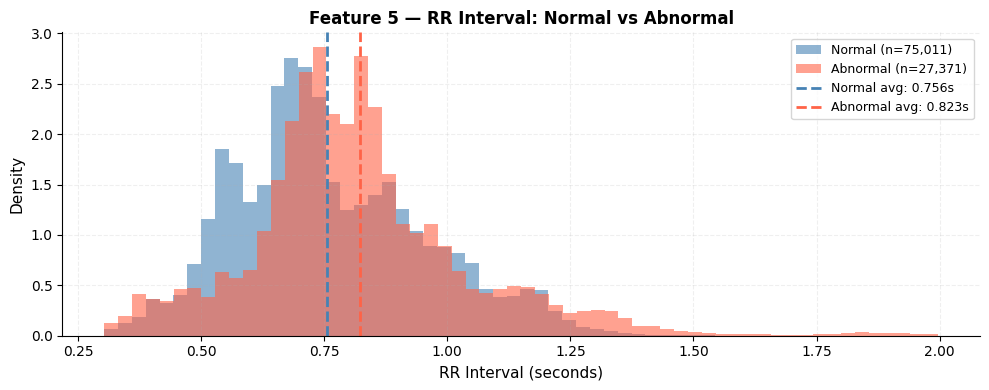

In [25]:
# Recalculate RR interval from original annotation positions


rr_values = []
rr_labels = []

for rec_name in sorted(os.listdir(data_path)):
    if not rec_name.endswith('.hea'):
        continue

    record_name = rec_name.replace('.hea', '')

    try:
        annotation = wfdb.rdann(os.path.join(data_path, record_name), 'atr')
        ann_samples = annotation.sample
        ann_symbols = annotation.symbol

        record = wfdb.rdrecord(os.path.join(data_path, record_name))
        signal = record.p_signal[:, 0]

        for i, (sample, symbol) in enumerate(zip(ann_samples, ann_symbols)):

            if symbol not in valid_beats:
                continue

            if sample - before < 0 or sample + after >= len(signal):
                continue

            # Calculate RR interval
            if i < len(ann_samples) - 1:
                rr = (ann_samples[i+1] - sample) / 360
            elif i > 0:
                rr = (sample - ann_samples[i-1]) / 360
            else:
                rr = 0.0

            rr_values.append(rr)
            rr_labels.append(0 if symbol == 'N' else 1)

    except Exception as e:
        print(f"Could not process {record_name}: {e}")

rr_values = np.array(rr_values)
rr_labels = np.array(rr_labels)

print(f"RR interval calculated for all {len(rr_values):,} beats")
print(f"\nFirst 10 beats:")
for i in range(10):
    label_name = "Normal" if rr_labels[i] == 0 else "Abnormal"
    print(f"  Beat {i}: RR = {rr_values[i]:.4f} sec  → {label_name}")

# Separate Normal and Abnormal
normal_rr = rr_values[rr_labels == 0]
abnormal_rr = rr_values[rr_labels == 1]

print(f"\nNormal beats ({len(normal_rr):,} beats):")
print(f"  Average RR interval: {np.mean(normal_rr):.4f} sec")
print(f"  Average heart rate:  {60/np.mean(normal_rr):.1f} bpm")
print(f"  Std:                 {np.std(normal_rr):.4f} sec")
print(f"  Min: {np.min(normal_rr):.4f}  Max: {np.max(normal_rr):.4f}")

print(f"\nAbnormal beats ({len(abnormal_rr):,} beats):")
print(f"  Average RR interval: {np.mean(abnormal_rr):.4f} sec")
print(f"  Average heart rate:  {60/np.mean(abnormal_rr):.1f} bpm")
print(f"  Std:                 {np.std(abnormal_rr):.4f} sec")
print(f"  Min: {np.min(abnormal_rr):.4f}  Max: {np.max(abnormal_rr):.4f}")

print(f"\nDifference in average RR interval:")
diff = np.mean(abnormal_rr) - np.mean(normal_rr)
print(f"  Abnormal − Normal = {diff:.4f} sec")
if diff < 0:
    print(f"  Abnormal beats arrive EARLIER than Normal beats")
else:
    print(f"  Abnormal beats arrive LATER than Normal beats")

# Breakdown by beat type
print(f"\nAverage RR interval by beat type:")
for beat_type in ['N', 'L', 'R', 'V', 'A']:
    indices = np.where(y == beat_type)[0]
    if len(indices) > 0:
        avg_rr = np.mean(rr_values[indices])
        avg_hr = 60 / avg_rr
        print(f"  {beat_type}: {avg_rr:.4f} sec = {avg_hr:.1f} bpm")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

# Limit to reasonable RR range for cleaner plot
mask_n = (normal_rr > 0.3) & (normal_rr < 2.0)
mask_a = (abnormal_rr > 0.3) & (abnormal_rr < 2.0)

ax.hist(normal_rr[mask_n], bins=60, alpha=0.6,
        color='steelblue', label=f'Normal (n={len(normal_rr):,})',
        density=True)
ax.hist(abnormal_rr[mask_a], bins=60, alpha=0.6,
        color='tomato', label=f'Abnormal (n={len(abnormal_rr):,})',
        density=True)
ax.axvline(np.mean(normal_rr), color='steelblue',
           linestyle='--', linewidth=2,
           label=f'Normal avg: {np.mean(normal_rr):.3f}s')
ax.axvline(np.mean(abnormal_rr), color='tomato',
           linestyle='--', linewidth=2,
           label=f'Abnormal avg: {np.mean(abnormal_rr):.3f}s')
ax.set_title('Feature 5 — RR Interval: Normal vs Abnormal',
             fontsize=12, fontweight='bold')
ax.set_xlabel('RR Interval (seconds)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Observations : RR interval

- Surprisingly Abnormal beats have a LONGER average RR interval
  (0.823 sec) than Normal beats (0.756 sec) — the opposite of
  what was initially expected
- This is explained by the compensatory pause effect — after a
  PVC or premature beat fires early the heart takes longer to
  reset before the next beat, making the measured RR interval
  appear longer
- Normal beats have the fastest average heart rate at 79.4 bpm
  while all Abnormal types show slower rates (70-76 bpm)
- Bundle Branch Block patients (L and R) tend to have naturally
  slower heart rates due to their underlying cardiac condition
- Abnormal beats show higher RR variation (std 0.269 vs 0.202)
  indicating more irregular rhythm — a clinically meaningful
  finding
- The maximum RR for Abnormal beats reaches 5.872 seconds
  indicating some patients had very long pauses between beats
- RR interval still contributes useful information to the ML
  model — particularly the variation and the per-beat-type
  differences — even though the direction of difference was
  unexpected

### Feature 6 : Skewness and Kurtosis
Skewness measures whether the voltage distribution of a beat leans
left or right — a tall spike pulling to the right creates positive
skewness. Kurtosis measures how sharp or flat the peak is — a tall
narrow spike like a Normal beat produces high kurtosis while a wide
rounded peak like a PVC beat produces lower kurtosis. Together these
two features capture the overall shape characteristics of each beat
type in a way that individual voltage measurements cannot.

Skewness and Kurtosis calculated for all 102,382 beats

First 10 beats:
  Beat 0: skew = 5.100  kurt = 30.914  → Normal
  Beat 1: skew = 5.975  kurt = 41.715  → Normal
  Beat 2: skew = 5.654  kurt = 39.149  → Normal
  Beat 3: skew = 5.652  kurt = 39.483  → Normal
  Beat 4: skew = 5.526  kurt = 37.606  → Normal
  Beat 5: skew = 5.683  kurt = 37.869  → Normal
  Beat 6: skew = 5.688  kurt = 37.719  → Abnormal
  Beat 7: skew = 5.333  kurt = 33.712  → Normal
  Beat 8: skew = 5.714  kurt = 38.723  → Normal
  Beat 9: skew = 5.976  kurt = 41.835  → Normal

── Skewness ──
Normal beats (75,011 beats):
  Average skewness: 3.0926
  Std:              1.6541
  Min: -3.8805  Max: 6.4908

Abnormal beats (27,371 beats):
  Average skewness: 1.3288
  Std:              1.6298
  Min: -3.3936  Max: 6.4645

Difference: -1.7638

Average skewness by beat type:
  N: 3.0926
  L: 1.5336
  R: 1.2963
  V: 0.6388
  A: 1.5996

── Kurtosis ──
Normal beats (75,011 beats):
  Average kurtosis: 15.9141
  Std:             

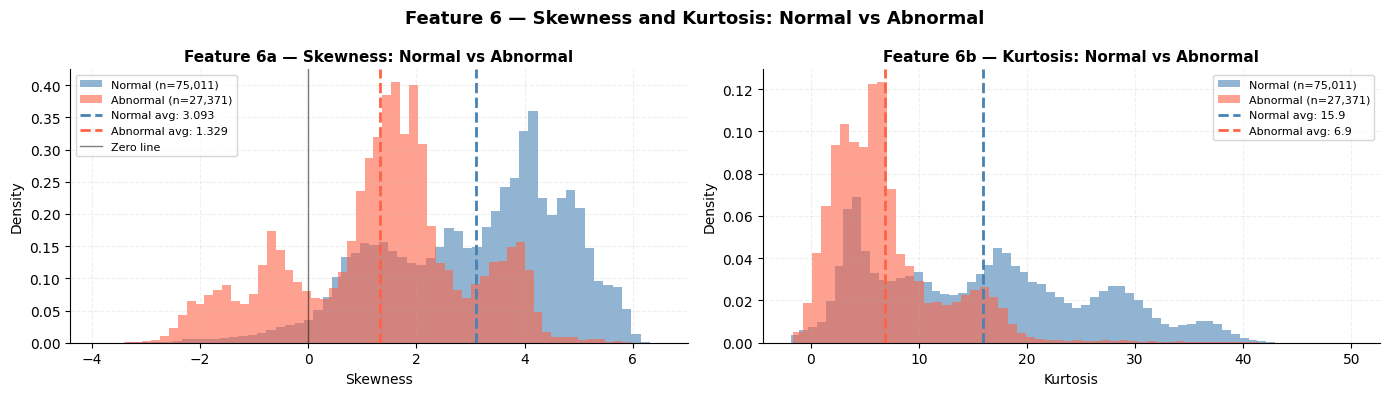

In [26]:
from scipy import stats

# Calculate skewness and kurtosis for every beat
skew_values = np.array([stats.skew(X[i]) for i in range(len(X))])
kurt_values = np.array([stats.kurtosis(X[i]) for i in range(len(X))])

print(f"Skewness and Kurtosis calculated for all {len(skew_values):,} beats")
print(f"\nFirst 10 beats:")
for i in range(10):
    label_name = "Normal" if y_binary[i] == 0 else "Abnormal"
    print(f"  Beat {i}: skew = {skew_values[i]:.3f}  kurt = {kurt_values[i]:.3f}  → {label_name}")

#  Skewness
normal_skew = skew_values[y_binary == 0]
abnormal_skew = skew_values[y_binary == 1]

print(f"\n── Skewness ──")
print(f"Normal beats ({len(normal_skew):,} beats):")
print(f"  Average skewness: {np.mean(normal_skew):.4f}")
print(f"  Std:              {np.std(normal_skew):.4f}")
print(f"  Min: {np.min(normal_skew):.4f}  Max: {np.max(normal_skew):.4f}")

print(f"\nAbnormal beats ({len(abnormal_skew):,} beats):")
print(f"  Average skewness: {np.mean(abnormal_skew):.4f}")
print(f"  Std:              {np.std(abnormal_skew):.4f}")
print(f"  Min: {np.min(abnormal_skew):.4f}  Max: {np.max(abnormal_skew):.4f}")

print(f"\nDifference: {np.mean(abnormal_skew) - np.mean(normal_skew):.4f}")

print(f"\nAverage skewness by beat type:")
for beat_type in ['N', 'L', 'R', 'V', 'A']:
    indices = np.where(y == beat_type)[0]
    print(f"  {beat_type}: {np.mean(skew_values[indices]):.4f}")

#  Kurtosis
normal_kurt = kurt_values[y_binary == 0]
abnormal_kurt = kurt_values[y_binary == 1]

print(f"\n── Kurtosis ──")
print(f"Normal beats ({len(normal_kurt):,} beats):")
print(f"  Average kurtosis: {np.mean(normal_kurt):.4f}")
print(f"  Std:              {np.std(normal_kurt):.4f}")
print(f"  Min: {np.min(normal_kurt):.4f}  Max: {np.max(normal_kurt):.4f}")

print(f"\nAbnormal beats ({len(abnormal_kurt):,} beats):")
print(f"  Average kurtosis: {np.mean(abnormal_kurt):.4f}")
print(f"  Std:              {np.std(abnormal_kurt):.4f}")
print(f"  Min: {np.min(abnormal_kurt):.4f}  Max: {np.max(abnormal_kurt):.4f}")

print(f"\nDifference: {np.mean(abnormal_kurt) - np.mean(normal_kurt):.4f}")

print(f"\nAverage kurtosis by beat type:")
for beat_type in ['N', 'L', 'R', 'V', 'A']:
    indices = np.where(y == beat_type)[0]
    print(f"  {beat_type}: {np.mean(kurt_values[indices]):.4f}")

#Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Skewness plot
axes[0].hist(normal_skew, bins=60, alpha=0.6,
             color='steelblue', label=f'Normal (n={len(normal_skew):,})',
             density=True)
axes[0].hist(abnormal_skew, bins=60, alpha=0.6,
             color='tomato', label=f'Abnormal (n={len(abnormal_skew):,})',
             density=True)
axes[0].axvline(np.mean(normal_skew), color='steelblue',
                linestyle='--', linewidth=2,
                label=f'Normal avg: {np.mean(normal_skew):.3f}')
axes[0].axvline(np.mean(abnormal_skew), color='tomato',
                linestyle='--', linewidth=2,
                label=f'Abnormal avg: {np.mean(abnormal_skew):.3f}')
axes[0].axvline(0, color='black', linestyle='-',
                linewidth=1, alpha=0.5, label='Zero line')
axes[0].set_title('Feature 6a — Skewness: Normal vs Abnormal',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Skewness', fontsize=10)
axes[0].set_ylabel('Density', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Kurtosis plot — limit range for cleaner view
mask_n = normal_kurt < 60
mask_a = abnormal_kurt < 60
axes[1].hist(normal_kurt[mask_n], bins=60, alpha=0.6,
             color='steelblue', label=f'Normal (n={len(normal_kurt):,})',
             density=True)
axes[1].hist(abnormal_kurt[mask_a], bins=60, alpha=0.6,
             color='tomato', label=f'Abnormal (n={len(abnormal_kurt):,})',
             density=True)
axes[1].axvline(np.mean(normal_kurt), color='steelblue',
                linestyle='--', linewidth=2,
                label=f'Normal avg: {np.mean(normal_kurt):.1f}')
axes[1].axvline(np.mean(abnormal_kurt), color='tomato',
                linestyle='--', linewidth=2,
                label=f'Abnormal avg: {np.mean(abnormal_kurt):.1f}')
axes[1].set_title('Feature 6b — Kurtosis: Normal vs Abnormal',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Kurtosis', fontsize=10)
axes[1].set_ylabel('Density', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Feature 6 — Skewness and Kurtosis: Normal vs Abnormal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations :Skewness and Kurtosis

Skewness:
- Normal beats have average skewness of 3.093: more than double
  the Abnormal average of 1.329
- The difference of 1.764 is large, skewness is a powerful feature
- Normal beats have a dominant tall spike that strongly pulls the
  voltage distribution to the right creating high positive skewness
- PVC beats (V) have the lowest skewness at 0.639: barely a
  quarter of Normal, confirming their wide rounded shape

Kurtosis:
- Kurtosis shows the largest difference of all features so far,
  Normal beats average 15.914 vs Abnormal average of 6.880
- The difference of 9.034 is by far the biggest gap seen across
  all features, making kurtosis the most powerful individual
  feature for classification
- Normal beats have one dominant sharp spike creating extreme
  kurtosis while Abnormal beats have wider more complex shapes
- PVC beats (V) have the lowest kurtosis at 3.150 — barely one
  fifth of Normal, confirming they are the most visually
  distinct beat type
- Kurtosis will likely be the top contributing feature in the
  SHAP analysis in Phase 5

### Feature 7: Range, Maximum and Minimum
Range measures the total voltage swing from the lowest to the
highest point in each beat. Maximum captures the peak voltage
(usually the R-peak tip) and minimum captures the deepest dip
(usually the S wave). Together these three features describe the
overall size and amplitude of the electrical signal — complementing
the shape features captured by skewness and kurtosis.

Max, Min and Range calculated for all 102,382 beats

First 10 beats:
  Beat 0: max=0.940  min=-0.535  range=1.475  → Normal
  Beat 1: max=0.960  min=-0.570  range=1.530  → Normal
  Beat 2: max=0.860  min=-0.645  range=1.505  → Normal
  Beat 3: max=0.820  min=-0.565  range=1.385  → Normal
  Beat 4: max=0.885  min=-0.545  range=1.430  → Normal
  Beat 5: max=0.945  min=-0.535  range=1.480  → Normal
  Beat 6: max=0.875  min=-0.570  range=1.445  → Abnormal
  Beat 7: max=0.885  min=-0.575  range=1.460  → Normal
  Beat 8: max=0.890  min=-0.585  range=1.475  → Normal
  Beat 9: max=0.925  min=-0.545  range=1.470  → Normal

── Maximum ──
Normal:   avg = 1.1705 mV
Abnormal: avg = 1.2124 mV
Difference: 0.0419 mV

── Minimum ──
Normal:   avg = -0.8590 mV
Abnormal: avg = -1.1084 mV
Difference: -0.2493 mV

── Range ──
Normal:   avg = 2.0296 mV
Abnormal: avg = 2.3208 mV
Difference: 0.2912 mV

Average range by beat type:
  N: max=1.171  min=-0.859  range=2.030
  L: max=1.187  min=-0.886  range=2.073
  

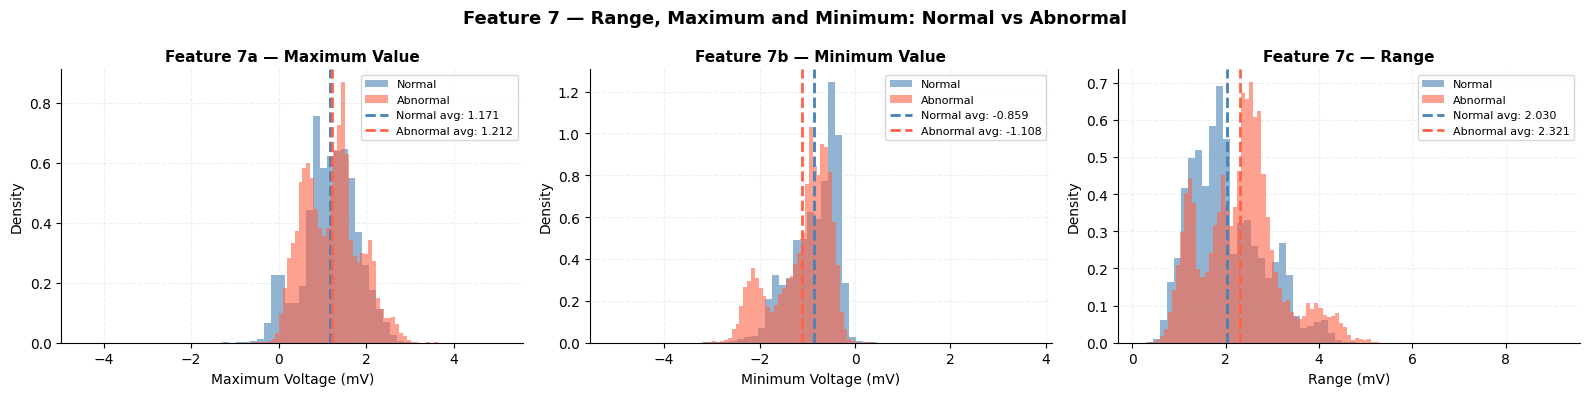

In [27]:
# Calculate max, min and range for every beat
max_values = np.max(X, axis=1)
min_values = np.min(X, axis=1)
range_values = max_values - min_values

print(f"Max, Min and Range calculated for all {len(max_values):,} beats")
print(f"\nFirst 10 beats:")
for i in range(10):
    label_name = "Normal" if y_binary[i] == 0 else "Abnormal"
    print(f"  Beat {i}: max={max_values[i]:.3f}  min={min_values[i]:.3f}  range={range_values[i]:.3f}  → {label_name}")

# Separate Normal and Abnormal
normal_max = max_values[y_binary == 0]
abnormal_max = max_values[y_binary == 1]
normal_min = min_values[y_binary == 0]
abnormal_min = min_values[y_binary == 1]
normal_range = range_values[y_binary == 0]
abnormal_range = range_values[y_binary == 1]

print(f"\n── Maximum ──")
print(f"Normal:   avg = {np.mean(normal_max):.4f} mV")
print(f"Abnormal: avg = {np.mean(abnormal_max):.4f} mV")
print(f"Difference: {np.mean(abnormal_max) - np.mean(normal_max):.4f} mV")

print(f"\n── Minimum ──")
print(f"Normal:   avg = {np.mean(normal_min):.4f} mV")
print(f"Abnormal: avg = {np.mean(abnormal_min):.4f} mV")
print(f"Difference: {np.mean(abnormal_min) - np.mean(normal_min):.4f} mV")

print(f"\n── Range ──")
print(f"Normal:   avg = {np.mean(normal_range):.4f} mV")
print(f"Abnormal: avg = {np.mean(abnormal_range):.4f} mV")
print(f"Difference: {np.mean(abnormal_range) - np.mean(normal_range):.4f} mV")

print(f"\nAverage range by beat type:")
for beat_type in ['N', 'L', 'R', 'V', 'A']:
    indices = np.where(y == beat_type)[0]
    avg_max = np.mean(max_values[indices])
    avg_min = np.mean(min_values[indices])
    avg_range = np.mean(range_values[indices])
    print(f"  {beat_type}: max={avg_max:.3f}  min={avg_min:.3f}  range={avg_range:.3f}")

# Plot all three side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Maximum plot
axes[0].hist(normal_max, bins=60, alpha=0.6,
             color='steelblue', label=f'Normal',
             density=True)
axes[0].hist(abnormal_max, bins=60, alpha=0.6,
             color='tomato', label=f'Abnormal',
             density=True)
axes[0].axvline(np.mean(normal_max), color='steelblue',
                linestyle='--', linewidth=2,
                label=f'Normal avg: {np.mean(normal_max):.3f}')
axes[0].axvline(np.mean(abnormal_max), color='tomato',
                linestyle='--', linewidth=2,
                label=f'Abnormal avg: {np.mean(abnormal_max):.3f}')
axes[0].set_title('Feature 7a — Maximum Value',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Maximum Voltage (mV)', fontsize=10)
axes[0].set_ylabel('Density', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Minimum plot
axes[1].hist(normal_min, bins=60, alpha=0.6,
             color='steelblue', label=f'Normal',
             density=True)
axes[1].hist(abnormal_min, bins=60, alpha=0.6,
             color='tomato', label=f'Abnormal',
             density=True)
axes[1].axvline(np.mean(normal_min), color='steelblue',
                linestyle='--', linewidth=2,
                label=f'Normal avg: {np.mean(normal_min):.3f}')
axes[1].axvline(np.mean(abnormal_min), color='tomato',
                linestyle='--', linewidth=2,
                label=f'Abnormal avg: {np.mean(abnormal_min):.3f}')
axes[1].set_title('Feature 7b — Minimum Value',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Minimum Voltage (mV)', fontsize=10)
axes[1].set_ylabel('Density', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Range plot
axes[2].hist(normal_range, bins=60, alpha=0.6,
             color='steelblue', label=f'Normal',
             density=True)
axes[2].hist(abnormal_range, bins=60, alpha=0.6,
             color='tomato', label=f'Abnormal',
             density=True)
axes[2].axvline(np.mean(normal_range), color='steelblue',
                linestyle='--', linewidth=2,
                label=f'Normal avg: {np.mean(normal_range):.3f}')
axes[2].axvline(np.mean(abnormal_range), color='tomato',
                linestyle='--', linewidth=2,
                label=f'Abnormal avg: {np.mean(abnormal_range):.3f}')
axes[2].set_title('Feature 7c — Range',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Range (mV)', fontsize=10)
axes[2].set_ylabel('Density', fontsize=10)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.2, linestyle='--')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle('Feature 7 — Range, Maximum and Minimum: Normal vs Abnormal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations — Range, Maximum and Minimum

Maximum:
- Abnormal beats have a slightly HIGHER maximum (1.212
  mV) than Normal beats (1.171 mV)
- PVC beats (V) have the highest maximum at 1.433 mV — some PVC
  beats produce very tall spikes
- Atrial Premature beats (A) have the lowest maximum at 0.821 mV —
  the heart fired early before full ventricular charge

Minimum:
- Abnormal beats go significantly deeper (−1.108 mV) than Normal
  beats (−0.859 mV) — a difference of 0.249 mV
- PVC beats (V) have the deepest minimum at −1.473 mV — large
  electrical swings in both directions
- Right Bundle Branch Block (R) also shows deep minimum at −1.262
  mV due to the backward travelling electrical signal
- Atrial Premature beats (A) have the shallowest minimum at −0.747
  mV — even less negative than Normal

Range:
- Abnormal beats have a larger overall range (2.321 mV) than Normal
  beats (2.030 mV) — difference of 0.291 mV
- PVC beats (V) have by far the largest range at 2.905 mV — nearly
  43% larger than Normal — confirming the most dramatic electrical
  swings of all beat types
- Atrial Premature beats (A) have the smallest range at 1.568 mV —
  even smaller than Normal — confirming they are the mildest
  abnormality in the dataset
- Range is a strong feature — its difference of 0.291 mV is
  comparable to R-peak amplitude at 0.297 mV

### Feature 8 : Mean first half and mean second half
Splitting the 360 sample window into two equal halves captures
different phases of the heartbeat separately. The first half
(samples 0-179) covers the baseline and P wave — the preparation
phase. The second half (samples 180-359) covers the S wave and
T wave — the recovery phase. This separation reveals information
that the overall mean feature misses — particularly differences
in P wave presence and T wave direction between beat types.

Mean first half and second half calculated for all 102,382 beats

First 10 beats:
  Beat 0: 1st half=-0.2733  2nd half=-0.3463  diff=-0.0729  → Normal
  Beat 1: 1st half=-0.3151  2nd half=-0.3496  diff=-0.0345  → Normal
  Beat 2: 1st half=-0.3359  2nd half=-0.3300  diff=0.0059  → Normal
  Beat 3: 1st half=-0.3099  2nd half=-0.3540  diff=-0.0440  → Normal
  Beat 4: 1st half=-0.3046  2nd half=-0.3469  diff=-0.0424  → Normal
  Beat 5: 1st half=-0.2914  2nd half=-0.3143  diff=-0.0229  → Normal
  Beat 6: 1st half=-0.3186  2nd half=-0.3445  diff=-0.0259  → Abnormal
  Beat 7: 1st half=-0.3383  2nd half=-0.3733  diff=-0.0350  → Normal
  Beat 8: 1st half=-0.3202  2nd half=-0.3476  diff=-0.0275  → Normal
  Beat 9: 1st half=-0.2936  2nd half=-0.3239  diff=-0.0302  → Normal

 Mean First Half (baseline + P wave) 
Normal:   avg = -0.3598 mV
Abnormal: avg = -0.2514 mV
Difference: 0.1083 mV

 Mean Second Half (S wave + T wave) 
Normal:   avg = -0.3442 mV
Abnormal: avg = -0.3237 mV
Difference: 0.0205 m

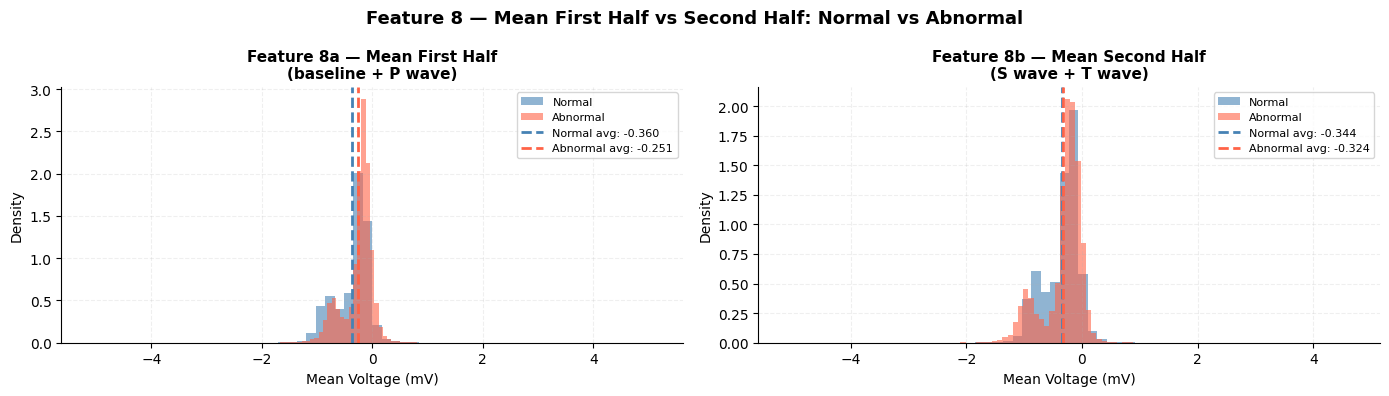

In [28]:
# Split each beat into two halves and calculate mean of each
first_half_means = np.mean(X[:, :180], axis=1)
second_half_means = np.mean(X[:, 180:], axis=1)

# Also calculate the difference between halves
half_difference = second_half_means - first_half_means

print(f"Mean first half and second half calculated for all {len(first_half_means):,} beats")
print(f"\nFirst 10 beats:")
for i in range(10):
    label_name = "Normal" if y_binary[i] == 0 else "Abnormal"
    print(f"  Beat {i}: 1st half={first_half_means[i]:.4f}  2nd half={second_half_means[i]:.4f}  diff={half_difference[i]:.4f}  → {label_name}")

# Separate Normal and Abnormal
normal_first = first_half_means[y_binary == 0]
abnormal_first = first_half_means[y_binary == 1]
normal_second = second_half_means[y_binary == 0]
abnormal_second = second_half_means[y_binary == 1]
normal_diff = half_difference[y_binary == 0]
abnormal_diff = half_difference[y_binary == 1]

print(f"\n Mean First Half (baseline + P wave) ")
print(f"Normal:   avg = {np.mean(normal_first):.4f} mV")
print(f"Abnormal: avg = {np.mean(abnormal_first):.4f} mV")
print(f"Difference: {np.mean(abnormal_first) - np.mean(normal_first):.4f} mV")

print(f"\n Mean Second Half (S wave + T wave) ")
print(f"Normal:   avg = {np.mean(normal_second):.4f} mV")
print(f"Abnormal: avg = {np.mean(abnormal_second):.4f} mV")
print(f"Difference: {np.mean(abnormal_second) - np.mean(normal_second):.4f} mV")

print(f"\n Half Difference (2nd - 1st) ")
print(f"Normal:   avg = {np.mean(normal_diff):.4f} mV")
print(f"Abnormal: avg = {np.mean(abnormal_diff):.4f} mV")
print(f"Difference: {np.mean(abnormal_diff) - np.mean(normal_diff):.4f} mV")

print(f"\nAverage by beat type:")
print(f"{'Type':<6} {'1st half':>10} {'2nd half':>10} {'difference':>12}")
print(f"{'─'*42}")
for beat_type in ['N', 'L', 'R', 'V', 'A']:
    indices = np.where(y == beat_type)[0]
    avg_first = np.mean(first_half_means[indices])
    avg_second = np.mean(second_half_means[indices])
    avg_diff = avg_second - avg_first
    print(f"  {beat_type:<4} {avg_first:>10.4f} {avg_second:>10.4f} {avg_diff:>12.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# First half plot
axes[0].hist(normal_first, bins=60, alpha=0.6,
             color='steelblue', label=f'Normal',
             density=True)
axes[0].hist(abnormal_first, bins=60, alpha=0.6,
             color='tomato', label=f'Abnormal',
             density=True)
axes[0].axvline(np.mean(normal_first), color='steelblue',
                linestyle='--', linewidth=2,
                label=f'Normal avg: {np.mean(normal_first):.3f}')
axes[0].axvline(np.mean(abnormal_first), color='tomato',
                linestyle='--', linewidth=2,
                label=f'Abnormal avg: {np.mean(abnormal_first):.3f}')
axes[0].set_title('Feature 8a — Mean First Half\n(baseline + P wave)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Mean Voltage (mV)', fontsize=10)
axes[0].set_ylabel('Density', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Second half plot
axes[1].hist(normal_second, bins=60, alpha=0.6,
             color='steelblue', label=f'Normal',
             density=True)
axes[1].hist(abnormal_second, bins=60, alpha=0.6,
             color='tomato', label=f'Abnormal',
             density=True)
axes[1].axvline(np.mean(normal_second), color='steelblue',
                linestyle='--', linewidth=2,
                label=f'Normal avg: {np.mean(normal_second):.3f}')
axes[1].axvline(np.mean(abnormal_second), color='tomato',
                linestyle='--', linewidth=2,
                label=f'Abnormal avg: {np.mean(abnormal_second):.3f}')
axes[1].set_title('Feature 8b — Mean Second Half\n(S wave + T wave)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Mean Voltage (mV)', fontsize=10)
axes[1].set_ylabel('Density', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Feature 8 — Mean First Half vs Second Half: Normal vs Abnormal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations: Mean first half and second half

Mean first half:
- Abnormal beats have a LESS negative first half (−0.251 mV) than
  Normal beats (−0.360 mV), a difference of 0.108 mV
- Right Bundle Branch Block (R) has the most negative first half
  at −0.442 mV due to its inverted electrical pattern
- L, V and A beats all show less negative baselines than Normal
  suggesting higher pre-beat voltage levels in these conditions

Mean second half:
- The second half shows smaller differences between Normal and
  Abnormal (0.020 mV), recovery patterns are more similar overall
- Right Bundle Branch Block again shows the most negative second
  half at −0.535 mV, the inverted T wave pulls the recovery
  phase deeply negative

Half difference:
- Normal beats show a positive half difference (+0.016), the
  second half is slightly less negative as the T wave recovers
- All Abnormal beat types show negative half differences, the
  second half becomes MORE negative than the first
- PVC beats show the largest drop (−0.114), no P wave in the
  first half and large inverted T wave in the second half creates
  the most dramatic difference between halves
- This half difference feature effectively captures T wave
  inversion and P wave absence, two key clinical indicators
  of abnormal heartbeats